# Estimating VaR via a Monte Carlo Simulation 

In [11]:
import numpy as np
import pandas as pd 
import datetime as dt 
import yfinance as yf 
import matplotlib.pyplot as plt 
from scipy.stats import norm 

## Data Ingestion

In [12]:
# Time Span
years = 15 
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days= 365*years)

# Tickers
tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

data = yf.download(tickers, start= start_date, end= end_date, auto_adjust=True)['Close']
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,BND,GLD,QQQ,SPY,VTI
Date,,,,,
2011-02-07,51.830093,131.679993,50.566406,100.956680,52.326569
2011-02-08,51.666771,133.139999,50.899696,101.415695,52.587959
2011-02-09,51.790916,133.070007,50.812004,101.186180,52.449589
2011-02-10,51.627598,132.850006,50.890938,101.224419,52.511093
2011-02-11,51.803944,132.320007,51.259327,101.828728,52.857044


## Compute Log Returns 

In [13]:
log_returns = np.log(data / data.shift(1))
log_returns = log_returns.dropna()

log_returns.head()

Ticker,BND,GLD,QQQ,SPY,VTI
Date,,,,,
2011-02-08,-0.003156,0.011027,0.006570,0.004536,0.004983
2011-02-09,0.002400,-0.000526,-0.001724,-0.002266,-0.002635
2011-02-10,-0.003158,-0.001655,0.001552,0.000378,0.001172
2011-02-11,0.003410,-0.003997,0.007213,0.005952,0.006567
2011-02-14,0.001134,0.004750,0.002393,0.002402,0.002615


In [14]:
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean()*weights)

def standard_deviation(weights, cov):
    variance = weights.T @ cov @ weights
    return np.sqrt(variance)

In [15]:
cov = log_returns.cov()
print(cov)

Ticker       BND       GLD       QQQ       SPY       VTI
Ticker                                                  
BND     0.000010  0.000009  0.000002  0.000001  0.000001
GLD     0.000009  0.000103  0.000006  0.000005  0.000005
QQQ     0.000002  0.000006  0.000171  0.000132  0.000135
SPY     0.000001  0.000005  0.000132  0.000118  0.000120
VTI     0.000001  0.000005  0.000135  0.000120  0.000123


## Portfolio Value, Expected Return and Standard Deviation

In [16]:
portfolio_value = 1000000 # 1 Million 
weights = np.array([1/len(tickers)]*len(tickers))

portfolio_expected_return = expected_return(weights, log_returns)
portfolio_std_dev = standard_deviation(weights, cov)

## Z Score

In [17]:
def random_z_score(): 
    return np.random.normal(0,1)

In [18]:
days = 5 

def scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days):
    return portfolio_value* portfolio_expected_return * days + portfolio_value*portfolio_std_dev*z_score*np.sqrt(days)

## Run 10000 Simulations

In [19]:
simulations = 10000
scenario_return = []

for i in range(simulations): 
    z_score = random_z_score()
    scenario_return.append(scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days))

## Specify a confidence level and Calculate the Value at Risk (VaR)

In [22]:
confidence_interval = 0.95
VaR = - np.percentile(scenario_return, 100*(1-confidence_interval))
print(VaR)

24957.89323523333


## Plotting

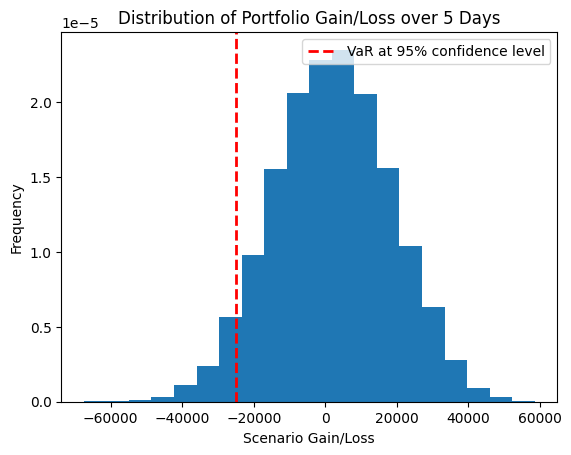

In [23]:
plt.hist(scenario_return, bins=20, density=True)
plt.xlabel('Scenario Gain/Loss')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio Gain/Loss over {days} Days')
plt.axvline(-VaR, color='r', linestyle='dashed', linewidth=2, label = f'VaR at {confidence_interval:.0%} confidence level')
plt.legend()
plt.show()